In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM

/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM


# Clone Repository

In [ ]:
!git clone -b gsconvns-fix --single-branch https://github.com/hilmizr/HaYOLO.git

Cloning into 'HaYOLO'...
remote: Enumerating objects: 38887, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 38887 (delta 18), reused 11 (delta 11), pack-reused 38864 (from 3)
Receiving objects: 100% (38887/38887), 23.20 MiB | 16.60 MiB/s, done.
Resolving deltas: 100% (28268/28268), done.
Updating files: 100% (766/766), done.


# Install Libraries

In [ ]:
!pip install roboflow gdown thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

# Import Libraries

In [ ]:
import os
import shutil
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from IPython.display import display
from PIL import Image
import cv2
import json
from shutil import copyfile
import sys
import os
import requests
from pathlib import Path
import random
import pathlib

# Setup Custom YOLO

In [ ]:
sys.path.append("/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO")
# Import YOLO directly from the ultralytics packagea
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics.models import yolo
from ultralytics.nn.modules import GSConv, C3Ghost, CBAM, GSConvns, GSBottleneck, GSBottleneckC, VoVGSCSP, VoVGSCSPC, ASPP, RFB, C3GS, C3k2GS, C3k2Ghost

## Define Custom Architecture

In [ ]:
#customize iPython writefile so we can write variables
from IPython.core.magic import register_line_cell_magic
@register_line_cell_magic
def writetemplate(line, cell):
    with open(line, 'w') as f:
        f.write(cell.format(**globals()))

In [ ]:
# ["yolov11n_baseline", "yolov11n_cbam_c3k2ghost", "yolov11n_cbam_ghostconv_c3k2ghost", "yolov11n_cbam_ghostconv", "yolov11n_cbam"]
model_name = "yolov11n_baseline"
yaml_path = f"/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/custom_yaml/final_variants/{model_name}.yaml"

## Compile Model

In [ ]:
modif_model = YOLO(yaml_path)

# Setup Dataset

## Download Dataset

In [ ]:
DATASET_TYPE = "ENHANCED_FAJRA"

In [ ]:
if DATASET_TYPE == "ORIGINAL":
  FILE_ID = "1zkqt7GQViegIqZnObSA87GsWrBn22I6c"
  data_yaml_path = r'/content/DUO-dataset-2/content/DUO-dataset-2/content/DUO_yolo_70_20_10/data.yaml'
  test_folder = r'/content/DUO-dataset-2/content/DUO-dataset-2/content/DUO_yolo_70_20_10/test/images'
elif DATASET_TYPE == "ENHANCED_FAJRA":
  FILE_ID = "1RJ5LAck-o7KhcdQ_9vEXB9_XFy10BjG9"
  data_yaml_path = r'/content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/data.yaml'
  test_folder = r'/content/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images'

In [ ]:
OUTPUT = "DUO-dataset-apm.zip"

In [ ]:
import gdown
gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)
!unzip -q DUO-dataset-apm.zip -d DUO-dataset-apm

Downloading...
From (original): https://drive.google.com/uc?id=1RJ5LAck-o7KhcdQ_9vEXB9_XFy10BjG9
From (redirected): https://drive.google.com/uc?id=1RJ5LAck-o7KhcdQ_9vEXB9_XFy10BjG9&confirm=t&uuid=c6a22d40-3730-48f5-926f-5c6ba0a33071
To: /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm.zip
100%|██████████| 1.48G/1.48G [00:17<00:00, 83.3MB/s]


# Modeling

In [ ]:
modif_model.train(
    data='/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/data.yaml',
    epochs=300,

    # spatial / batch
    imgsz=640,            # will train on 640×640 images (3 channels assumed)
    batch=16,             # batch size

    # optimizer & LR schedule
    optimizer='SGD',      # stochastic gradient descent
    lr0=0.01,             # initial learning rate
    lrf=0.1,              # final learning rate factor (multiplied by lr0 at end of training)
    momentum=0.937,       # SGD momentum
    weight_decay=0.0005,  # L2 regularization factor

    # early stopping & checkpointing
    patience=100,
    save=True,
    save_period=-1,

    device=0
)

New https://pypi.org/project/ultralytics/8.3.158 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.143 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/con

100%|██████████| 755k/755k [00:00<00:00, 22.3MB/s]

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

 23        [16, 19, 22]  1    431452  ultralytics.nn.modules.head.Detect           [4, [64, 128, 256]]           
YOLOv11n_baseline summary: 181 layers, 2,590,620 parameters, 2,590,604 gradients, 6.4 GFLOPs

Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 72.9MB/s]


...

                   all       1515      14302      0.839      0.735      0.821      0.609



300 epochs completed in 3.856 hours.
Optimizer stripped from /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/train2/weights/last.pt, 5.5MB
Optimizer stripped from /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/train2/weights/best.pt, 5.5MB

Validating /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/train2/weights/best.pt...
Ultralytics 8.3.143 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLOv11n_baseline summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [00:11<00:00,  4.36it/s]


                   all       1515      14302      0.828       0.74      0.821      0.609
               echinus        663       1503      0.842      0.722      0.829      0.589
           holothurian       1351       9731      0.897      0.838      0.929      0.715
               scallop        101        320      0.708      0.547      0.616      0.423
              starfish        921       2748      0.864      0.854       0.91       0.71
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3029011110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

# Evaluate

## Assess GFLOPs, Parameters, and Size

In [ ]:
best_weights = '/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/train2/weights/best.pt'
best_model   = YOLO(best_weights)
print("----- Detailed Model Summary (verbose) -----")
best_model.info(verbose=True)
size_bytes = os.path.getsize(best_weights)
size_mb    = size_bytes / (1024 ** 2)
print(f"Checkpoint file size: {size_mb:.2f} MB")

----- Detailed Model Summary (verbose) -----
YOLOv11n_baseline summary: 181 layers, 2,590,620 parameters, 0 gradients, 6.4 GFLOPs
Checkpoint file size: 5.25 MB


In [ ]:
pip install thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

In [ ]:
# Save model summary
with open("model_summary.txt", "w") as f:
    f.write("----- Model Summary -----\n")
    f.write(f"Parameters: {params:,}\n")
    f.write(f"Checkpoint file size: {size_mb:.2f} MB\n")
    f.write(f"GFLOPs: {gflops:.2f}\n")

## Evaluate on Test Set

In [ ]:
test_results = best_model.val(
    data='/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/data.yaml',
    split='test',
    batch=16,
    imgsz=640,
    save_json=True,
    save_txt=True,
    plots=True,
    verbose=True
)

Ultralytics 8.3.143 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
YOLOv11n_baseline summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 104.1±36.2 MB/s, size: 189.9 KB)


val: Scanning /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/labels... 763 images, 2 backgrounds, 1 corrupt: 100%|██████████| 763/763 [00:04<00:00, 153.61it/s]

val: /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/3783.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0002]


val: New cache created: /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [00:42<00:00,  1.14it/s]


                   all        762       7195        0.8      0.784      0.841      0.631
               echinus        346        810      0.791      0.762      0.822      0.574
           holothurian        669       4726      0.886      0.854      0.931      0.716
               scallop         62        243      0.675      0.654      0.691      0.506
              starfish        473       1416      0.847      0.867      0.919      0.727
Speed: 0.4ms preprocess, 2.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Saving /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/val/predictions.json...
Results saved to /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/val


In [ ]:
precision = test_results.box.mp
recall = test_results.box.mr
f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

In [ ]:
# Print key metrics
print(f"Test mAP50: {test_results.box.map50:.4f}")
print(f"Test mAP50-95: {test_results.box.map:.4f}")
print(f"Test mAP75: {test_results.box.map75:.4f}")
print(f"Test Precision: {test_results.box.mp:.4f}")
print(f"Test Recall: {test_results.box.mr:.4f}")
print(f"Test F1 Score: {f1_score:.4f}")

Test mAP50: 0.8408
Test mAP50-95: 0.6308
Test mAP75: 0.7165
Test Precision: 0.7997
Test Recall: 0.7843
Test F1 Score: 0.7919


In [ ]:
# Save test metrics
with open("test_metrics.txt", "w") as f:
    f.write("----- Test Metrics -----\n")
    f.write(f"Test mAP50: {test_results.box.map50:.4f}\n")
    f.write(f"Test mAP75: {test_results.box.map75:.4f}\n")
    f.write(f"Test mAP50-95: {test_results.box.map:.4f}\n")
    f.write(f"Test Precision: {test_results.box.mp:.4f}\n")
    f.write(f"Test Recall: {test_results.box.mr:.4f}\n")
    f.write(f"Test F1 Score: {f1_score:.4f}\n")

## Export Confusion Matrices as CSV

In [ ]:
cm_test = test_results.confusion_matrix.matrix
np.savetxt("cm_test.csv", cm_test, delimiter=",", fmt="%.0f")

## Export Per-Class Metrics

In [ ]:
# ---- Export Per-Class Metrics ----
num_classes = len(test_results.box.p)
per_class_metrics = pd.DataFrame({
    "Class ID": np.arange(num_classes),
    "Class Name": [best_model.names[i] for i in range(num_classes)],
    "Precision": test_results.box.p,
    "Recall": test_results.box.r,
    "F1 Score": test_results.box.f1,
    "AP50": test_results.box.ap50,
    "AP50-95": test_results.box.ap
})
per_class_metrics.to_csv("per_class_metrics.csv", index=False)
print("✅ Exported per_class_metrics.csv")

✅ Exported per_class_metrics.csv


## Plot LR Progression Against Loss & mAP

In [ ]:
results_csv = Path('/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/HaYOLO/runs/detect/train2/results.csv')
df = pd.read_csv(results_csv)
print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


In [ ]:
df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,53.4236,3.54983,3.54469,3.14629,0.11829,0.09322,0.09197,0.04625,2.30466,2.45293,2.38399,0.070098,0.003322,0.003322
1,2,102.1260,2.26750,2.41247,2.07317,0.17740,0.14207,0.16289,0.09281,1.85282,1.92488,1.86803,0.040078,0.006636,0.006636
2,3,151.0610,1.98657,2.10763,1.78134,0.52877,0.20433,0.21718,0.11377,1.79789,1.79048,1.76633,0.010038,0.009929,0.009929
3,4,198.7720,1.79404,1.81624,1.60321,0.84516,0.27057,0.30778,0.17427,1.57522,1.52912,1.56753,0.009910,0.009910,0.009910
4,5,246.4940,1.68411,1.66772,1.53343,0.71549,0.28682,0.32533,0.18348,1.52225,1.50957,1.50352,0.009880,0.009880,0.009880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,13701.7000,0.81420,0.50796,0.99162,0.82648,0.74036,0.82119,0.60932,0.85955,0.56241,1.03023,0.001150,0.001150,0.001150
296,297,13746.9000,0.80654,0.50623,0.98727,0.82796,0.73963,0.82092,0.60941,0.85950,0.56252,1.03022,0.001120,0.001120,0.001120
297,298,13791.9000,0.80854,0.50701,0.99051,0.83297,0.73826,0.82110,0.60945,0.85923,0.56245,1.03005,0.001090,0.001090,0.001090
298,299,13837.3000,0.80362,0.50217,0.98465,0.83748,0.73564,0.82109,0.60955,0.85924,0.56230,1.02996,0.001060,0.001060,0.001060


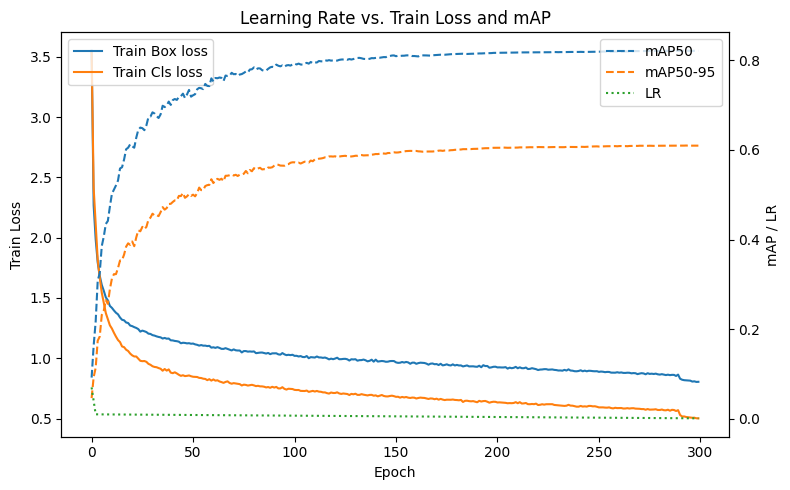

In [ ]:
# ===== Plot 1: Train Loss, mAP, LR =====
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot training losses
ax1.plot(df.index, df['train/box_loss'], label='Train Box loss')
ax1.plot(df.index, df['train/cls_loss'], label='Train Cls loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')
ax1.legend(loc='upper left')

# Twin axis for mAP and LR
ax2 = ax1.twinx()
ax2.plot(df.index, df['metrics/mAP50(B)'], '--', label='mAP50')
ax2.plot(df.index, df['metrics/mAP50-95(B)'], '--', label='mAP50-95')
ax2.plot(df.index, df['lr/pg0'], ':', label='LR')
ax2.set_ylabel('mAP / LR')
ax2.legend(loc='upper right')

plt.title('Learning Rate vs. Train Loss and mAP')
plt.tight_layout()
plt.savefig('train_loss_vs_map_lr.png', dpi=300)
plt.show()  # Show plot 1

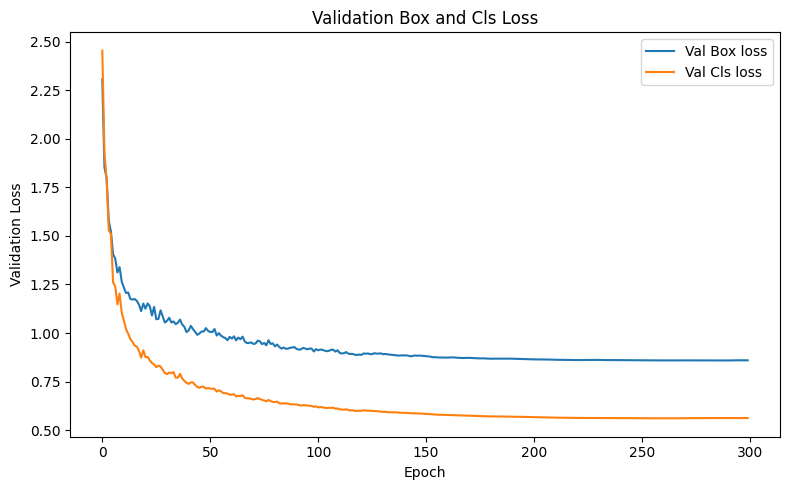

In [ ]:
# ===== Plot 2: Validation Losses =====
fig2, ax = plt.subplots(figsize=(8, 5))
ax.plot(df.index, df['val/box_loss'], label='Val Box loss')
ax.plot(df.index, df['val/cls_loss'], label='Val Cls loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.legend()
plt.title('Validation Box and Cls Loss')
plt.tight_layout()
plt.savefig('val_loss.png', dpi=300)
plt.show()  # Show plot 2

## Visualize Sample Object Detection


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/4352.jpg: 640x640 1 echinus, 11 holothurians, 1 starfish, 10.2ms
Speed: 2.1ms preprocess, 10.2ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


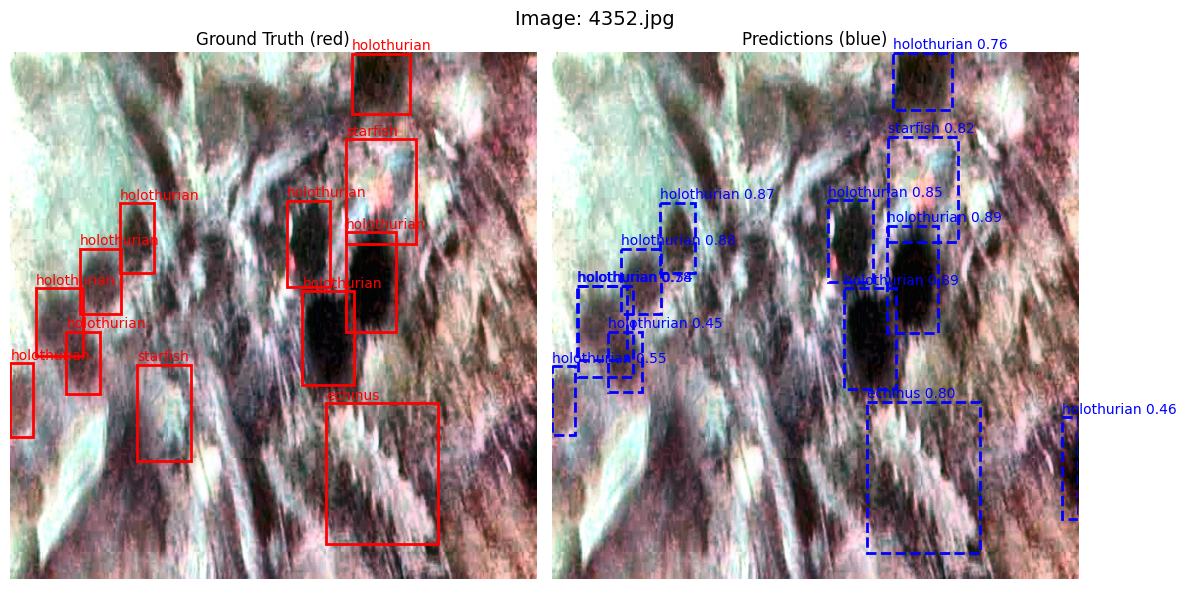


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/4908.jpg: 640x640 1 echinus, 11.1ms
Speed: 2.2ms preprocess, 11.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


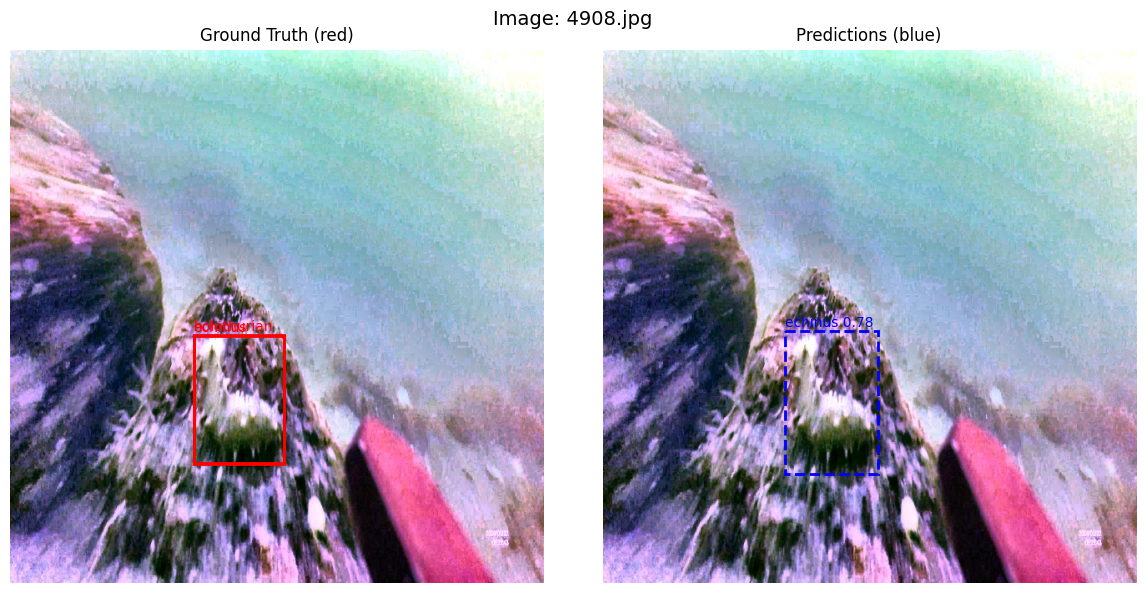


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/995.jpg: 640x640 53 holothurians, 1 starfish, 10.6ms
Speed: 2.7ms preprocess, 10.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


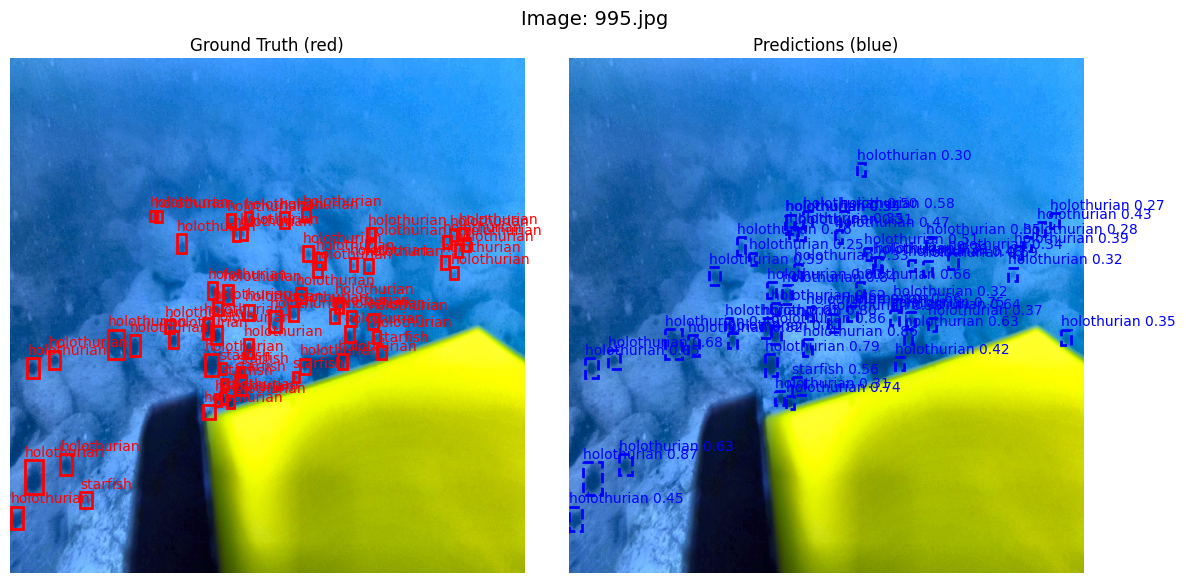


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/1632.jpg: 640x640 6 holothurians, 8 starfishs, 11.1ms
Speed: 2.8ms preprocess, 11.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


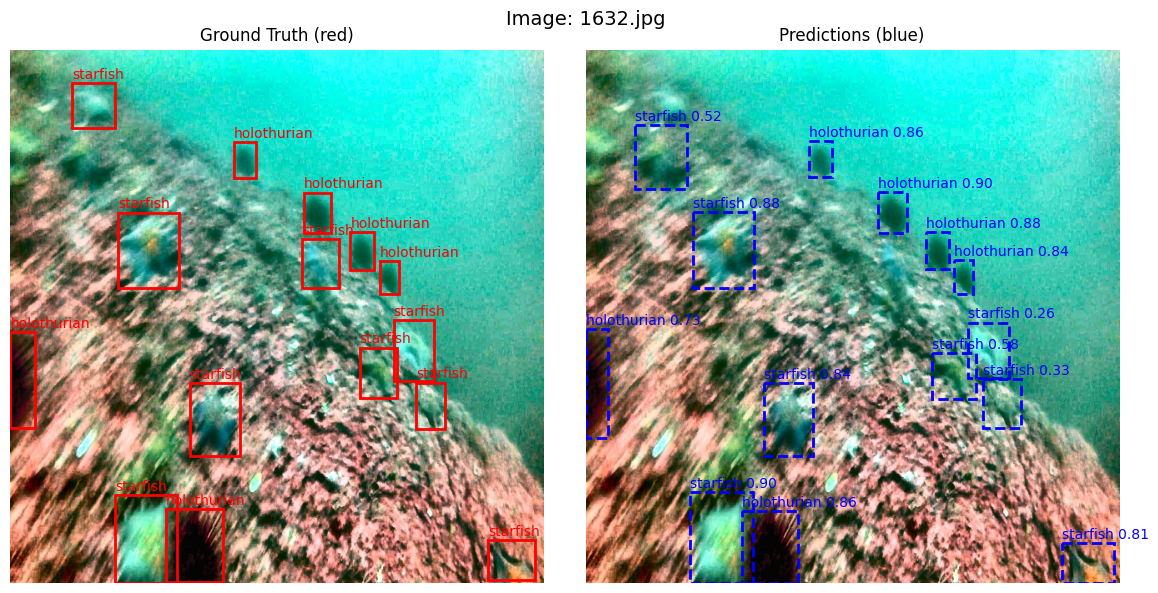


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/3219.jpg: 640x640 2 holothurians, 11.1ms
Speed: 2.7ms preprocess, 11.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


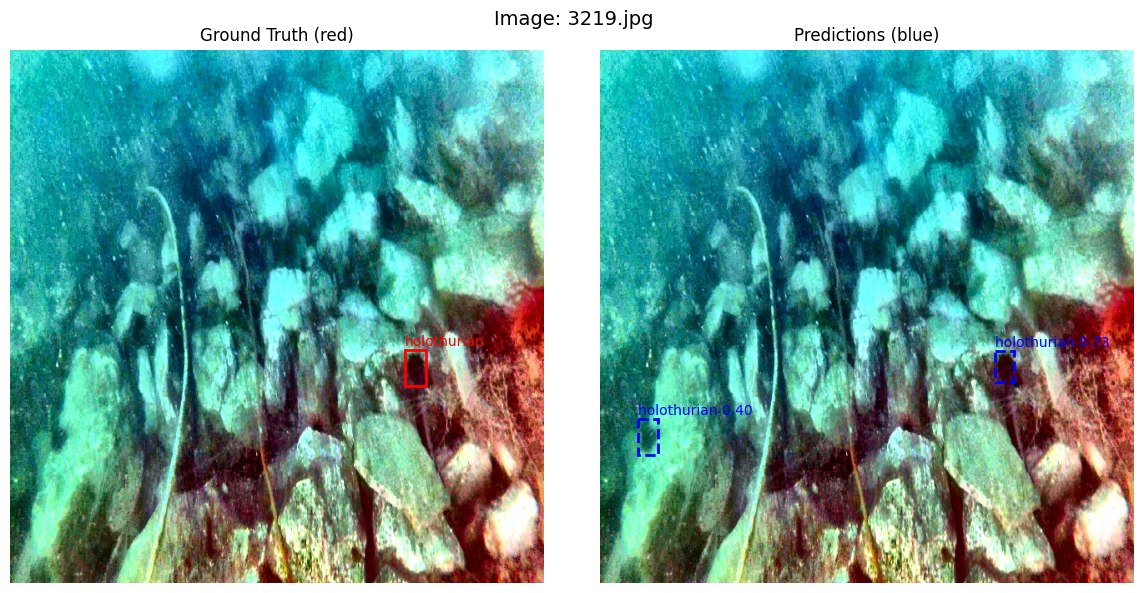

In [ ]:
test_images_dir = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images')
test_labels_dir = test_images_dir.parent / 'labels'

all_test_images = list(test_images_dir.glob('*.jpg')) + list(test_images_dir.glob('*.png'))
if not all_test_images:
    raise RuntimeError(f"No images found in {test_images_dir}")

N = 5
sample_images = random.sample(all_test_images, k=min(N, len(all_test_images)))

for img_path in sample_images:
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    results = best_model.predict(source=str(img_path), conf=0.25)
    preds   = results[0].boxes  # .boxes.xyxy, .boxes.cls, .boxes.conf

    label_file = test_labels_dir / f"{img_path.stem}.txt"
    gt_boxes = []
    if label_file.exists():
        with open(label_file, 'r') as f:
            for line in f:
                toks = line.split()
                if len(toks) < 5:
                    continue
                cls_id   = int(float(toks[0]))
                x_center = float(toks[1])
                y_center = float(toks[2])
                bw       = float(toks[3])
                bh       = float(toks[4])
                x_min = (x_center - bw / 2) * w
                y_min = (y_center - bh / 2) * h
                x_max = (x_center + bw / 2) * w
                y_max = (y_center + bh / 2) * h
                gt_boxes.append((int(x_min), int(y_min), int(x_max), int(y_max), cls_id))
    else:
        print(f"⚠️ Warning: No label file for {img_path.name}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax_gt, ax_pred = axes[0], axes[1]

    ax_gt.imshow(img_rgb)
    ax_gt.set_title("Ground Truth (red)")
    ax_gt.axis('off')
    for (xmin, ymin, xmax, ymax, cls_id) in gt_boxes:
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='red',
            facecolor='none',
            linestyle='-'
        )
        ax_gt.add_patch(rect)
        ax_gt.text(
            xmin,
            ymin - 5,
            f"{best_model.names[cls_id]}",
            color='red',
            fontsize=10
        )

    ax_pred.imshow(img_rgb)
    ax_pred.set_title("Predictions (blue)")
    ax_pred.axis('off')
    for box in preds:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls_id = int(box.cls.cpu().numpy()[0])
        conf   = float(box.conf.cpu().numpy()[0])
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='blue',
            facecolor='none',
            linestyle='--'
        )
        ax_pred.add_patch(rect)
        ax_pred.text(
            x1,
            y1 - 5,
            f"{best_model.names[cls_id]} {conf:.2f}",
            color='blue',
            fontsize=10
        )

    plt.suptitle(f"Image: {img_path.name}", fontsize=14)
    plt.tight_layout()
    plt.show()



image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/171.jpg: 640x640 2 holothurians, 12.3ms
Speed: 3.8ms preprocess, 12.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


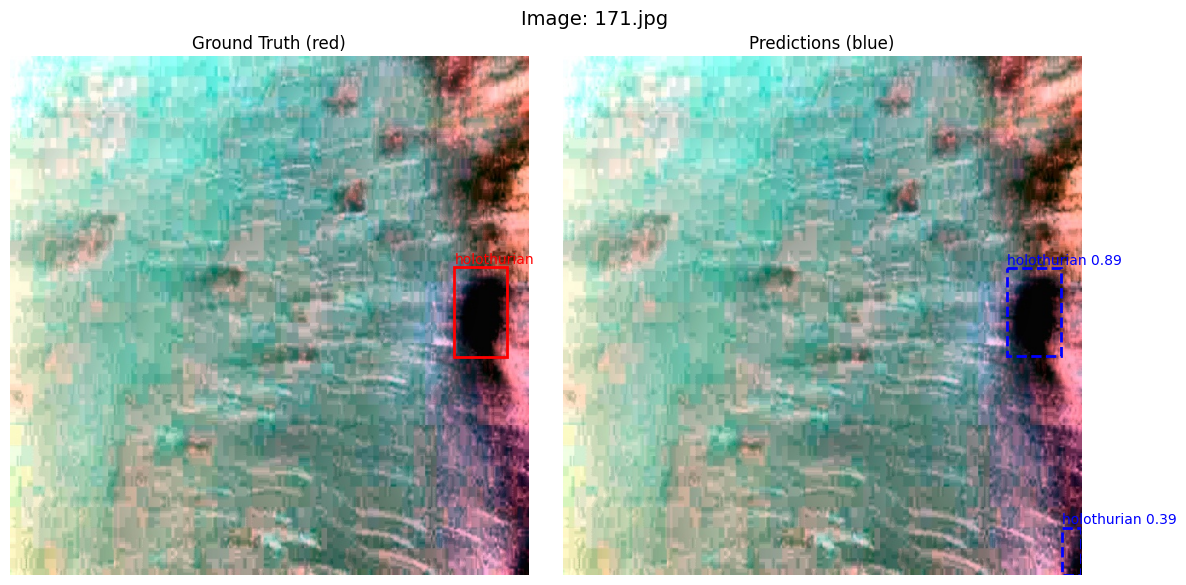


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/6549.jpg: 640x640 2 echinuss, 25 holothurians, 5 starfishs, 10.6ms
Speed: 2.7ms preprocess, 10.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


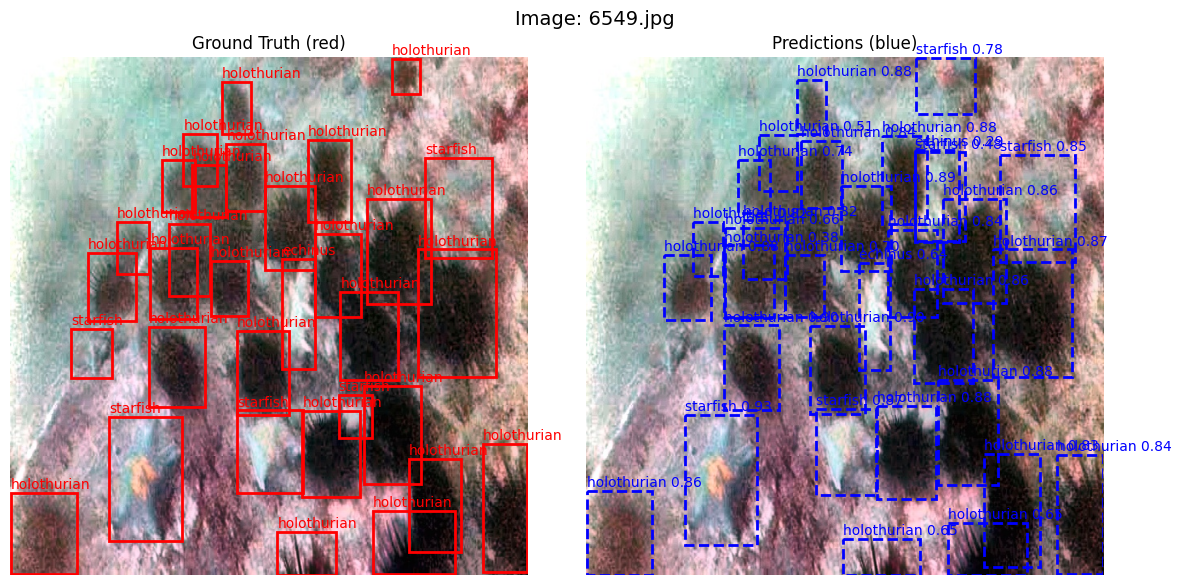


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/2237.jpg: 640x640 2 echinuss, 4 holothurians, 3 starfishs, 10.6ms
Speed: 2.1ms preprocess, 10.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


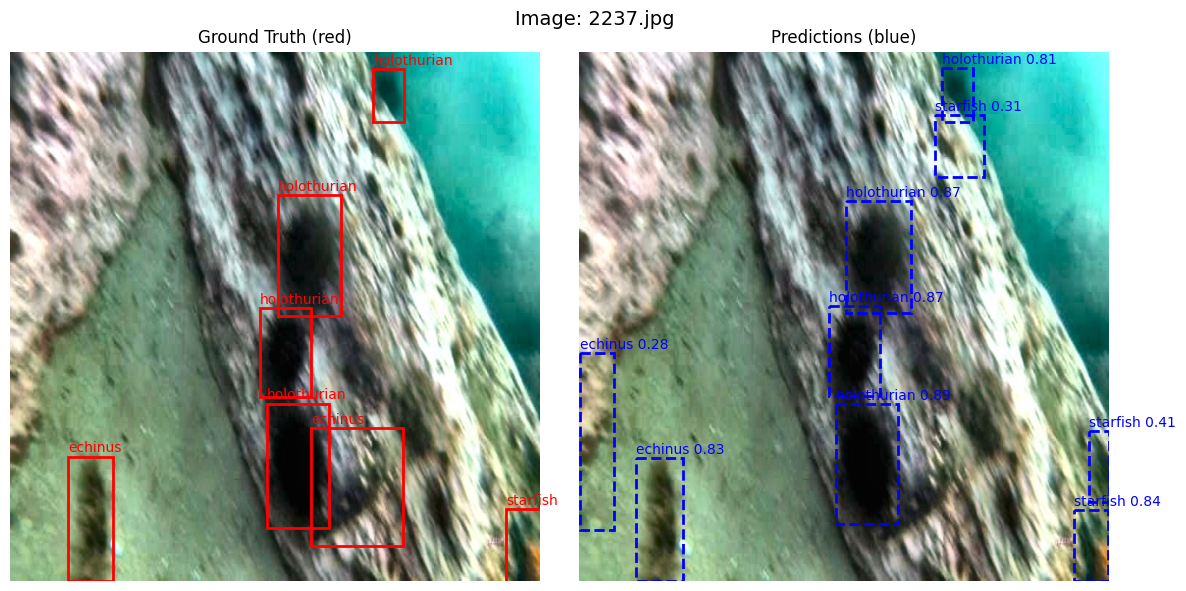


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/772.jpg: 640x640 3 holothurians, 11.2ms
Speed: 2.9ms preprocess, 11.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


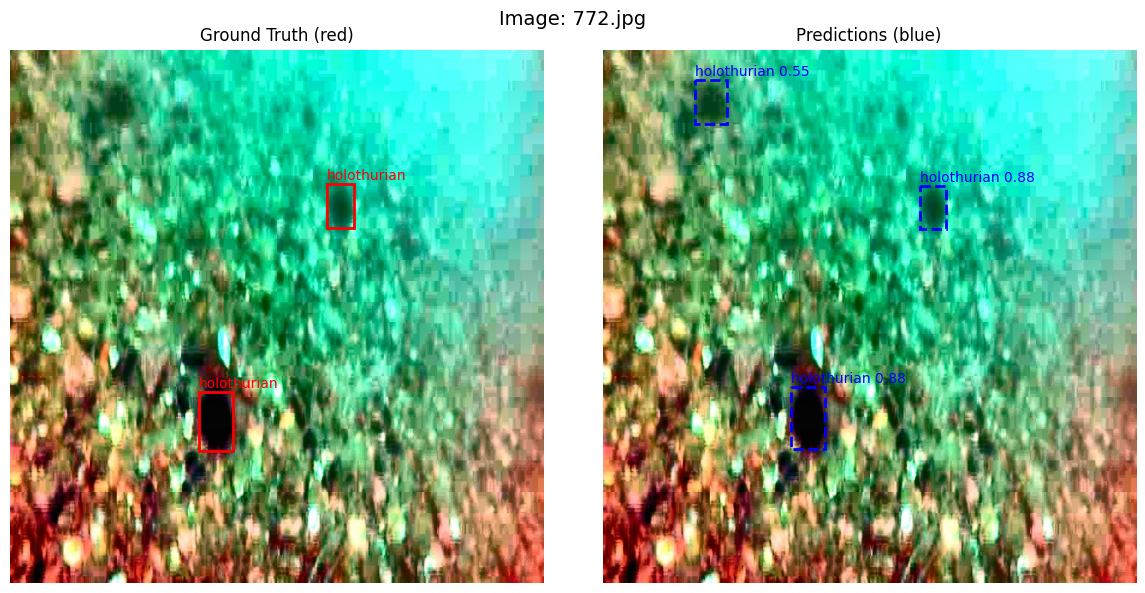


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/APM/DUO-dataset-apm/content/DUO-dataset-github-enhanced-rara/test/images/4900.jpg: 640x640 1 echinus, 10.6ms
Speed: 2.1ms preprocess, 10.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


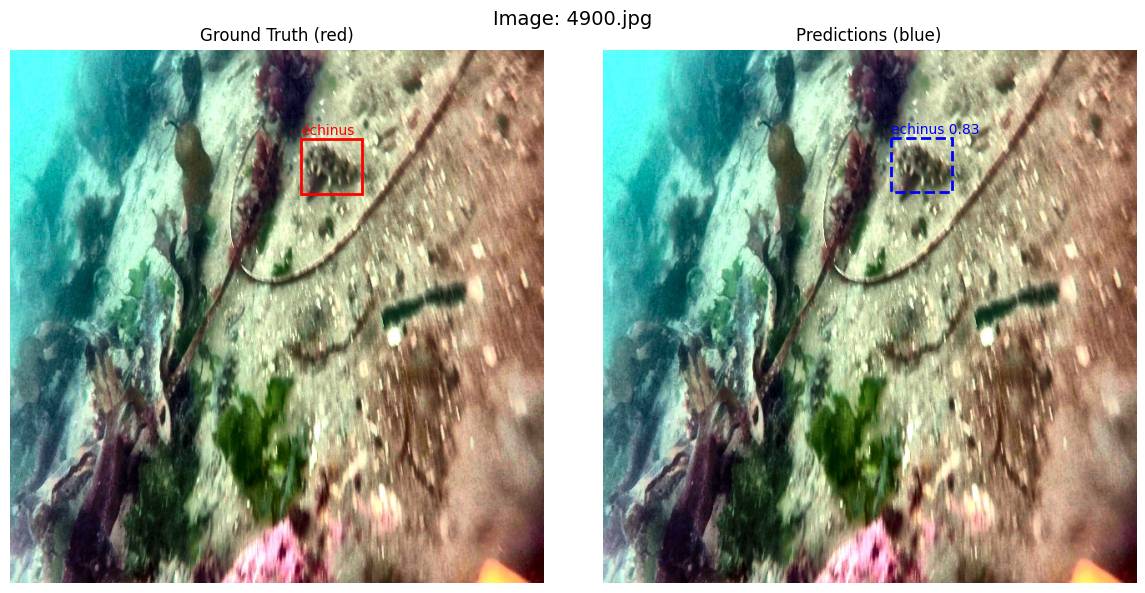

In [ ]:
output_dir = Path("sample_visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

N = 5
sample_images = random.sample(all_test_images, k=min(N, len(all_test_images)))

for img_path in sample_images:
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    results = best_model.predict(source=str(img_path), conf=0.25)
    preds   = results[0].boxes

    label_file = test_labels_dir / f"{img_path.stem}.txt"
    gt_boxes = []
    if label_file.exists():
        with open(label_file, 'r') as f:
            for line in f:
                toks = line.split()
                if len(toks) < 5:
                    continue
                cls_id   = int(float(toks[0]))
                x_center = float(toks[1])
                y_center = float(toks[2])
                bw       = float(toks[3])
                bh       = float(toks[4])
                x_min = (x_center - bw / 2) * w
                y_min = (y_center - bh / 2) * h
                x_max = (x_center + bw / 2) * w
                y_max = (y_center + bh / 2) * h
                gt_boxes.append((int(x_min), int(y_min), int(x_max), int(y_max), cls_id))
    else:
        print(f"⚠️ Warning: No label file for {img_path.name}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax_gt, ax_pred = axes[0], axes[1]

    ax_gt.imshow(img_rgb)
    ax_gt.set_title("Ground Truth (red)")
    ax_gt.axis('off')
    for (xmin, ymin, xmax, ymax, cls_id) in gt_boxes:
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax_gt.add_patch(rect)
        ax_gt.text(xmin, ymin - 5, f"{best_model.names[cls_id]}", color='red', fontsize=10)

    ax_pred.imshow(img_rgb)
    ax_pred.set_title("Predictions (blue)")
    ax_pred.axis('off')
    for box in preds:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls_id = int(box.cls.cpu().numpy()[0])
        conf   = float(box.conf.cpu().numpy()[0])
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
        ax_pred.add_patch(rect)
        ax_pred.text(x1, y1 - 5, f"{best_model.names[cls_id]} {conf:.2f}", color='blue', fontsize=10)

    plt.suptitle(f"Image: {img_path.name}", fontsize=14)
    plt.tight_layout()

    # ✅ Save the figure
    output_path = output_dir / f"{img_path.stem}_gt_vs_pred.png"
    plt.savefig(output_path, dpi=300)
    plt.show()


## Export Prediction Results as CSV

In [ ]:
# ---- Export Prediction Results ----
prediction_data = []
for img_path in all_test_images:
    results = best_model.predict(source=str(img_path), conf=0.25)
    preds = results[0].boxes
    for box in preds:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls.cpu().numpy()[0])
        conf = float(box.conf.cpu().numpy()[0])
        prediction_data.append({
            "Image": img_path.name,
            "Class ID": cls_id,
            "Class Name": best_model.names[cls_id],
            "Confidence": conf,
            "X1": x1,
            "Y1": y1,
            "X2": x2,
            "Y2": y2
        })
df_preds = pd.DataFrame(prediction_data)
df_preds.to_csv("prediction_results.csv", index=False)
print("✅ Exported prediction_results.csv")


image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/NewCustomModule/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/177.jpg: 640x640 2 echinuss, 6 holothurians, 3 starfishs, 10.8ms
Speed: 2.0ms preprocess, 10.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/NewCustomModule/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/3987.jpg: 640x640 31 holothurians, 4 starfishs, 10.3ms
Speed: 1.8ms preprocess, 10.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/underwater-viskom-final-project/NewCustomModule/DUO-dataset-2/content/DUO-dataset-github-enhanced-hilmi/test/images/1429.jpg: 640x640 7 holothurians, 12 starfishs, 10.0ms
Speed: 1.8ms preprocess, 10.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Co

## Export Results as Zip

In [ ]:
import datetime
from zipfile import ZipFile

# === Define dynamic export folder name based on YAML + timestamp ===
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
clean_dataset = DATASET_TYPE.replace(" ", "_")
export_name = f"{model_name}_{clean_dataset}_{timestamp}"
export_dir = Path(export_name)
export_dir.mkdir(parents=True, exist_ok=True)

# === List of files to export ===
export_files = [
    "cm_test.csv",
    "per_class_metrics.csv",
    "train_loss_vs_map_lr.png",
    "val_loss.png",
    "model_summary.txt",
    "test_metrics.txt",
    "prediction_results.csv",
    yaml_path
]
# === Copy export files into the export folder ===
for file in export_files:
    src = Path(file)
    dst = export_dir / f"{src.stem}_{export_name}{src.suffix}"
    shutil.copy(src, dst)

# === Copy best.pt and last.pt directly to the root of export folder ===
weights_dir = Path("/content/HaYOLO/runs/detect/train/weights")
for weight_name in ["best.pt", "last.pt"]:
    weight_path = weights_dir / weight_name
    if weight_path.exists():
        weight_stem = Path(weight_name).stem
        weight_suffix = Path(weight_name).suffix
        renamed = f"{weight_stem}_{export_name}{weight_suffix}"
        shutil.copy(weight_path, export_dir / renamed)

# === Copy sample visualizations ===
sample_vis_dir = Path("sample_visualizations")
sample_vis_export = export_dir / f"sample_visualizations_{export_name}"
shutil.copytree(sample_vis_dir, sample_vis_export)

# === Copy HaYOLO runs/detect directory ===
detect_src = Path("/content/HaYOLO/runs/detect")
detect_dst = export_dir / f"detect_outputs_{export_name}"
shutil.copytree(detect_src, detect_dst)

# === Zip the export directory ===
zip_filename = f"{export_name}.zip"
shutil.make_archive(base_name=export_name, format='zip', root_dir=export_dir)
print(f"✅ Zipped everything into {zip_filename}")


✅ Zipped everything into yolov11n_cbam_ghostconv_c3k2ghost_ENHANCED_HILMI_2025-06-21_04-20-55.zip


### Download From Google Colab

In [ ]:
from google.colab import files
files.download(f"{zip_filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Put in Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

drive_export_dir = Path("/content/drive/MyDrive/FinalYoloExports")
drive_export_dir.mkdir(parents=True, exist_ok=True)

shutil.copy(f"{zip_filename}", drive_export_dir / zip_filename)
print(f"✅ Copied {zip_filename} to Google Drive at {drive_export_dir}")

Mounted at /content/drive
✅ Copied yolov11n_cbam_ghostconv_c3k2ghost_ENHANCED_HILMI_2025-06-21_04-20-55.zip to Google Drive at /content/drive/MyDrive/FinalYoloExports
